In [74]:
# 1. Import dependencies
import getpass
from typing import Annotated, List, Optional, TypedDict, Any
from operator import or_
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from IPython.display import Image, display
import logging
from dotenv import load_dotenv
from firecrawl import FirecrawlApp

load_dotenv()
from langgraph.starter.agents.a3_react_agent.React_Agent import graph

In [75]:
# 2. Setting up configurations

############################ Logging configuration ###############################
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Remove all handlers associated with the root logger object
if logger.hasHandlers():
    logger.handlers.clear()

# Create a new handler
handler = logging.StreamHandler()
handler.setLevel(logging.INFO)

# Create a formatter and set it for the handler
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

# Add the handler to the root logger
logger.addHandler(handler)

def first_non_null(a, b):
    return a if a is not None else b

# todo-SH: Check below
FIRECRAWL_API_KEY = getpass.getpass("Firecrawl API Key: ")

In [76]:
# 3. Defining Application states

class InputState(TypedDict):
    url: str
    keyword: str

class OverallState(TypedDict):
    urls: List[str]
    current_url_index: int
    total_urls: int
    urls_to_scrape: List[str]
    extracted_info: Annotated[Optional[str], first_non_null]
    extracted_from_url: Annotated[Optional[str], first_non_null]
    is_information_found: Annotated[Optional[bool], or_]
    keyword: str

In [77]:
# 4. Defining nodes
def first_node(state: InputState) -> OverallState:
    logger.info("Executing node: first_node")
    return {
        "urls": [state["url"]],
        "current_url_index": 0,
        "total_urls": 0,
        "urls_to_scrape": [],
        "keyword": state["keyword"],
        "extracted_info": None,
        "extracted_from_url": None,
        "is_information_found": False,
    }

In [78]:
def get_sitemap(state: OverallState, config):
    logging.info("Executing node: get_sitemap")
    api_key = config.get("configurable", {}).get("firecrawl_api_key")
    if not api_key:
        logger.error("Firecrawl API key is missing in the configuration")
        raise ValueError("Firecrawl API key is missing in the configuration")

    app = FirecrawlApp(api_key=api_key)

    # Map the website to get the list of URLs
    map_result = app.map(state["urls"][0])
    logging.info(f"Map result: {map_result}")

    # Handle the new response format which is a dictionary
    if isinstance(map_result, dict):
        # todo-SH: Not sure about below line
        if map_result.get('success') and isinstance(map_result.get('links'), list):
            sitemap = map_result['links']
            state['urls'] = sitemap
            state['total_urls'] = len(sitemap)
            logging.info(f"Found {len(sitemap)} URLs to scrape.")
        else:
            logging.error(f"Error: Invalid response structure in map_result: {map_result}")
            state["urls"] = []

    # Keep the original list handling for backward compatibility
    elif isinstance(map_result, list) and len(map_result) > 0:
        sitemap = map_result
        state['urls'] = sitemap
        state['total_urls'] = len(sitemap)
        logging.info(f"Found {len(sitemap)} URLs to scrape.")
    else:
        logging.error(f"Error: Unexpected format in map_result: {map_result}")
        state['urls'] = []

    return state

In [79]:
def scrape_manager(state: OverallState) -> OverallState:
    logging.info("Executing node: scrape_manager")
    total_urls = state.get("total_urls", 0)
    current_index = state['current_url_index']
    next_index = min(current_index + 3, total_urls)
    urls_to_scrape = state['urls'][current_index:next_index] #todo-SH: Don't know about this line
    state['current_url_index'] = next_index # Update the current index
    state['urls_to_scrape'] = urls_to_scrape # Store the URLs to scrape

    if total_urls > 0:
        progress = (current_index / total_urls) * 100
        logging.info(f"Progress: {current_index}/{total_urls} URLS Processed ({progress:.2f}%)")
    return state

# router node: Function to return Send objects to scraper nodes
def continue_to_scraper(state: OverallState):
    logging.info(f"Preparing to scrape URLs {state['current_url_index'] - len(state['urls_to_scrape'])} to {state['current_url_index'] -1 }") #todo-SH: I have no idea
    # Return list of Send objects to 'scraper' node
    return [Send("scraper", {"url": url, "keyword": state["keyword"]}) for url in state['urls_to_scrape']]

In [80]:
def scraper(state: OverallState, config):
    url = state['url'] #todo-SH: Check this
    keyword = state['keyword']
    logging.info(f"Executing node: scrapper for URL: {url}")
    api_key = config.get("configurable", {}).get("firecrawl_api_key")
    if not api_key:
        logging.error("Firecrawl API key is missing in the configuration")
        raise ValueError("Firecrawl API key is missing in the configuration")

    app = FirecrawlApp(api_key=api_key)

    # Scrape the URL and get mark down
    try:
        logging.info(f"Started scraping: {url}")
        scrape_result = app.scrape(url, formats=['markdown'])
        logging.info(f"Scraped URL: {url}")
    except Exception as e:
        logging.error(f"Exception occurred while scraping url: {url}. Error: {e}")
        scrape_result = {}

    if isinstance(scrape_result, dict):
        markdown = scrape_result.get('markdown', "")

        # Check if keyword is in mark down
        if markdown and keyword in markdown:
            return {
                "extracted_info": markdown,
                "extracted_from_url": url,
                "is_information_found": True
            }
        else:
            return {"is_information_found": False}
    else:
        logging.warning(f"Failed to scrape URL: {url}")
        return {"is_information_found": False}

In [81]:

def evaluate(state: OverallState):
    logging.info("Executing node: evaluate")
    return state

def evaluate_routing(state: OverallState):
    if state.get("is_information_found", False):
        logging.info(f"Information found in URL: {state.get('extracted_from_url')}")
        logging.info("Terminating graph execution.")
        return "END"
    elif state['current_url_index'] < len(state['urls']):
        logging.info("Information not found, continuing to scrape next batch.")
        return "scrape_manager"
    else:
        logging.info("No more URLs to scrape, terminating graph execution")
        return "END"

In [82]:
# Build the graph with configuration schema
class ConfigSchema(TypedDict):
    firecrawl_api_key: str

builder = StateGraph(OverallState, input=InputState, config_schema=ConfigSchema)

builder.add_node("first_node", first_node)
builder.add_node("get_sitemap", get_sitemap)
builder.add_node("scrape_manager", scrape_manager)
builder.add_node("scraper", scraper)
builder.add_node("evaluate", evaluate)

builder.add_edge(START, "first_node")
builder.add_edge("first_node", "get_sitemap")
builder.add_edge("get_sitemap", "scrape_manager")

builder.add_conditional_edges("scrape_manager", continue_to_scraper, ["scraper"])
builder.add_edge("scraper", "evaluate")

builder.add_conditional_edges(
    "evaluate",
    evaluate_routing,
    {"END": END, "scrape_manager": "scrape_manager"}
)

graph = builder.compile()

/var/folders/qg/rns4vpgd4vs2htb6_yh8c2300000gq/T/ipykernel_86970/588304592.py:5: LangGraphDeprecatedSinceV10: `config_schema` is deprecated and will be removed. Please use `context_schema` instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, config_schema=ConfigSchema)
/var/folders/qg/rns4vpgd4vs2htb6_yh8c2300000gq/T/ipykernel_86970/588304592.py:5: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, config_schema=ConfigSchema)


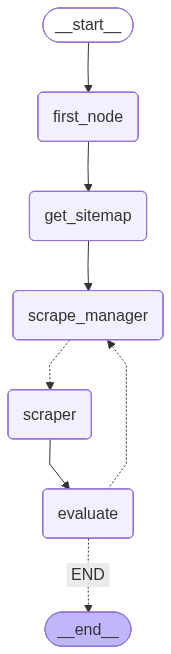

In [83]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [84]:
config = {
    "configurable": {
        "firecrawl_api_key": FIRECRAWL_API_KEY,
        "recursion_limit": 50
    }
}

input_state = {
    "url": "https://www.canadagoose.com/",
    "keyword": "Lodge Coach Jacket Black Label"
    # "url": "https://www.prothomalo.com/",
    # "keyword": "মেট্রােরেল"
}

result = graph.invoke(input_state, config=config)

2026-01-20 14:32:33,449 - INFO - Executing node: first_node
2026-01-20 14:32:33,450 - INFO - Executing node: get_sitemap
2026-01-20 14:32:36,845 - INFO - Map result: links=[LinkResult(url='https://www.canadagoose.com/us/en/pr/shelburne-parka-699363351616.html', title='Shelburne Parka | Canada Goose US', description='The perfect parka for frigid days that require maximum protection. Originally released in 2014, this style is one of our most-loved pieces today.'), LinkResult(url='https://www.canadagoose.com/us/en/pr/alessia-jacket-699363280084.html', title='Alessia Jacket | Canada Goose US', description='Prepare to get noticed. Featuring bold quilting and customizable details you’ll want to wear daily.'), LinkResult(url='https://www.canadagoose.com/us/en/pr/lawrence-puffer-black-label-2801MB.html', title='Lawrence Puffer Black Label | Canada Goose US', description='Embrace the elements all season long in the Lawrence Puffer.'), LinkResult(url='https://www.canadagoose.com/us/en/shop/men/o